In [ ]:
# Week 1 ( DataSet Understanding )

In [65]:
# Importing Libararies
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os

In [5]:
# Upload Dataset - Subset Files

print("Please upload files")
uploaded = files.upload()


Please upload files


Saving train_FD001.txt to train_FD001 (1).txt
Saving test_FD001.txt to test_FD001.txt


In [6]:
# Load Dataset

train = pd.read_csv('train_FD001.txt', sep=" ", header=None)
test = pd.read_csv('test_FD001.txt', sep=" ", header=None)

In [7]:
# Remove empty columns

train = train.dropna(axis=1, how='all')
test = test.dropna(axis=1, how='all')

In [8]:
# Assign column names

cols = ['engine_id', 'cycle'] + \
       [f'op_setting_{i}' for i in range(1,4)] + \
       [f'sensor_{i}' for i in range(1,22)]

train.columns = cols
test.columns = cols


In [ ]:
# Display basic information

print("TRAIN DATASET INFO")
print(f"Train Shape: {train.shape}")
print(f"Test Shape: {test.shape}")
print(f"Number of engines in train: {train['engine_id'].nunique()}")
print(f"Number of engines in test: {test['engine_id'].nunique()}")
print(f"Total cycles in train: {train['cycle'].sum()}")
print(f"Total cycles in test: {test['cycle'].sum()}")

TRAIN DATASET INFO
Train Shape: (20631, 26)
Test Shape: (13096, 26)
Number of engines in train: 100
Number of engines in test: 100
Total cycles in train: 2244815
Total cycles in test: 1006251


In [9]:
# Show first few rows

print("\nFirst 5 rows of training data:")
print(train.head())



First 5 rows of training data:
   engine_id  cycle  op_setting_1  op_setting_2  op_setting_3  sensor_1  \
0          1      1       -0.0007       -0.0004         100.0    518.67   
1          1      2        0.0019       -0.0003         100.0    518.67   
2          1      3       -0.0043        0.0003         100.0    518.67   
3          1      4        0.0007        0.0000         100.0    518.67   
4          1      5       -0.0019       -0.0002         100.0    518.67   

   sensor_2  sensor_3  sensor_4  sensor_5  ...  sensor_12  sensor_13  \
0    641.82   1589.70   1400.60     14.62  ...     521.66    2388.02   
1    642.15   1591.82   1403.14     14.62  ...     522.28    2388.07   
2    642.35   1587.99   1404.20     14.62  ...     522.42    2388.03   
3    642.35   1582.79   1401.87     14.62  ...     522.86    2388.08   
4    642.37   1582.85   1406.22     14.62  ...     522.19    2388.04   

   sensor_14  sensor_15  sensor_16  sensor_17  sensor_18  sensor_19  \
0    8138.62 

In [10]:
# Check for missing values

print("\nMissing values in train:", train.isnull().sum().sum())
print("Missing values in test:", test.isnull().sum().sum())


Missing values in train: 0
Missing values in test: 0


In [11]:
# Week 2 ( Data Cleaning and Feature Selection )

In [12]:
# Remove low variance and high correlation sensors

In [13]:
# Identify sensor columns

sensor_cols = [col for col in train.columns if 'sensor' in col]
print(f"\nTotal sensors initially: {len(sensor_cols)}")


Total sensors initially: 21


In [14]:
# 2.1 Remove low variance sensors (variance < 0.0001)

variances = train[sensor_cols].var()
low_var_cols = variances[variances < 0.0001].index.tolist()
train = train.drop(columns=low_var_cols)
test = test.drop(columns=low_var_cols)
print(f"Removed {len(low_var_cols)} low variance sensors")

Removed 7 low variance sensors


In [15]:
# Update sensor columns

sensor_cols = [col for col in train.columns if 'sensor' in col]
print(f"Sensors after low variance removal: {len(sensor_cols)}")

Sensors after low variance removal: 14


In [16]:
# 2.2 Remove highly correlated sensors (>0.95)

corr_matrix = train[sensor_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper.columns if any(upper[col] > 0.95)]

train = train.drop(columns=high_corr_cols)
test = test.drop(columns=high_corr_cols)
print(f"Removed {len(high_corr_cols)} highly correlated sensors")

Removed 1 highly correlated sensors


In [17]:
# Final sensor columns

sensor_cols = [col for col in train.columns if 'sensor' in col]
print(f"Final sensors selected: {len(sensor_cols)}")
print(f"Sensors: {sensor_cols}")

Final sensors selected: 13
Sensors: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [18]:
# Week 3 ( Normalization - Z Score Standardization )

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [19]:
# Fit on training data only, transform both train and test

train[sensor_cols] = scaler.fit_transform(train[sensor_cols])
test[sensor_cols] = scaler.transform(test[sensor_cols])

print("\nNormalization complete!")
print(f"Train mean after normalization: {train[sensor_cols].mean().mean():.6f}")
print(f"Train std after normalization: {train[sensor_cols].std().mean():.6f}")


Normalization complete!
Train mean after normalization: 0.000000
Train std after normalization: 1.000024


In [20]:
# Week 4 ( Window Segmentation and Anomaly Labeling )

window_size = 30  # As per specification
anomaly_ratio = 0.20  # Last 20% cycles considered anomalous

def create_windows(data, window_size):
    """
    Create sliding windows for each engine
    """
    X = []
    engine_ids = []

    for engine in data['engine_id'].unique():
        engine_data = data[data['engine_id'] == engine]
        for i in range(len(engine_data) - window_size):
            window = engine_data.iloc[i:i+window_size][sensor_cols].values
            X.append(window)
            engine_ids.append(engine)

    return np.array(X), engine_ids

def create_anomaly_labels(data, window_size, anomaly_ratio=0.20):
    """
    Label windows: 1 = anomaly (last 20% cycles), 0 = normal
    """
    labels = []

    for engine in data['engine_id'].unique():
        engine_data = data[data['engine_id'] == engine]
        max_cycle = engine_data['cycle'].max()
        anomaly_start_cycle = max_cycle - int(max_cycle * anomaly_ratio)

        for i in range(len(engine_data) - window_size):
            window_end_cycle = engine_data.iloc[i + window_size - 1]['cycle']
            if window_end_cycle >= anomaly_start_cycle:
                labels.append(1)  # anomaly
            else:
                labels.append(0)  # normal

    return np.array(labels)

In [21]:
# Create windows

print("\nCreating windows...")
X_train, train_engine_ids = create_windows(train, window_size)
X_test, test_engine_ids = create_windows(test, window_size)


Creating windows...


In [24]:
# Create labels

y_train = create_anomaly_labels(train, window_size, anomaly_ratio)
y_test = create_anomaly_labels(test, window_size, anomaly_ratio)

print(f"\nWindows created successfully!")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


Windows created successfully!
X_train shape: (17631, 30, 13)
X_test shape: (10096, 30, 13)
y_train shape: (17631,)
y_test shape: (10096,)


In [25]:
# Check class distribution

print(f"\nNormal samples in train: {(y_train==0).sum()} ({(y_train==0).sum()/len(y_train)*100:.2f}%)")
print(f"Anomaly samples in train: {(y_train==1).sum()} ({(y_train==1).sum()/len(y_train)*100:.2f}%)")


Normal samples in train: 13545 (76.82%)
Anomaly samples in train: 4086 (23.18%)


In [26]:
# Extract only normal samples for training

X_train_normal = X_train[y_train == 0]
print(f"\nTraining on normal samples only: {X_train_normal.shape}")


Training on normal samples only: (13545, 30, 13)


In [27]:
# Week 5 ( Dense Autoencoder Implementation )

In [28]:
# Baseline model with fully connected layers

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Flatten the windows for Dense Autoencoder
X_train_flat = X_train_normal.reshape(X_train_normal.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

input_dim = X_train_flat.shape[1]
print(f"Flattened input dimension: {input_dim}")

Flattened input dimension: 390


In [29]:
# Build Dense Autoencoder

input_layer = Input(shape=(input_dim,))
encoded = Dense(128, activation='relu')(input_layer)
encoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(input_dim, activation='linear')(decoded)

dense_ae = Model(input_layer, decoded)
dense_ae.compile(optimizer='adam', loss='mse')

print("\nDense Autoencoder Summary:")
dense_ae.summary()


Dense Autoencoder Summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 390)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        50,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 390)            │        50,310 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,934 (456.77 KB)

 Trainable params: 116,934 (456.77 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Early stopping callback

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [32]:
# Train the model

print("\nTraining Dense Autoencoder...")
history_dense = dense_ae.fit(
    X_train_flat, X_train_flat,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


Training Dense Autoencoder...
Epoch 1/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.3394 - val_loss: 0.2467
Epoch 2/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2455 - val_loss: 0.2407
Epoch 3/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2394 - val_loss: 0.2352
Epoch 4/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2340 - val_loss: 0.2297
Epoch 5/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2275 - val_loss: 0.2239
Epoch 6/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2213 - val_loss: 0.2182
Epoch 7/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2156 - val_loss: 0.2139
Epoch 8/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2110 - val_loss: 0.2115
Epoch 9/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2081 - val_loss: 0.2094
Epoch 10/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2064 - val_loss: 0.2081
Epoch 11/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2045 - val_loss: 0.2077
Epoch 12/50
191/191 

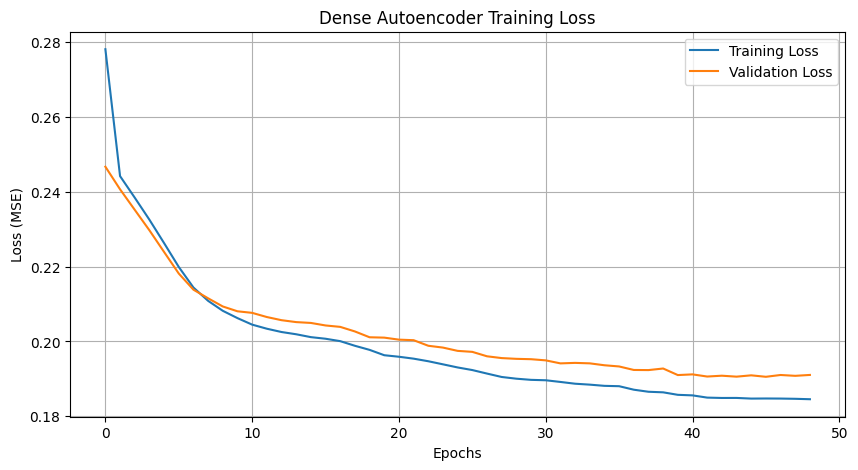

In [33]:
# Plot training history

plt.figure(figsize=(10, 5))
plt.plot(history_dense.history['loss'], label='Training Loss')
plt.plot(history_dense.history['val_loss'], label='Validation Loss')
plt.title('Dense Autoencoder Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [34]:
# Week 6  ( LSTM Autoencoder Implementation )

In [35]:
# Captures temporal dependencies

from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed

timesteps = X_train.shape[1]
features = X_train.shape[2]
print(f"Timesteps: {timesteps}, Features: {features}")

Timesteps: 30, Features: 13


In [36]:
# Build LSTM Autoencoder

input_layer = Input(shape=(timesteps, features))
encoded = LSTM(64, activation='tanh')(input_layer)
decoded = RepeatVector(timesteps)(encoded)
decoded = LSTM(64, activation='tanh', return_sequences=True)(decoded)
decoded = TimeDistributed(Dense(features))(decoded)

lstm_ae = Model(input_layer, decoded)
lstm_ae.compile(optimizer='adam', loss='mse')

print("\nLSTM Autoencoder Summary:")
lstm_ae.summary()


LSTM Autoencoder Summary:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 30, 13)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 13)         │           845 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,837 (210.30 KB)

 Trainable params: 53,837 (210.30 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# Train the model

print("\nTraining LSTM Autoencoder...")
history_lstm = lstm_ae.fit(
    X_train_normal, X_train_normal,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


Training LSTM Autoencoder...
Epoch 1/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.3200 - val_loss: 0.2472
Epoch 2/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.2462 - val_loss: 0.2426
Epoch 3/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2423 - val_loss: 0.2400
Epoch 4/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2398 - val_loss: 0.2388
Epoch 5/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2385 - val_loss: 0.2385
Epoch 6/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2373 - val_loss: 0.2373
Epoch 7/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2367 - val_loss: 0.2360
Epoch 8/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.2353 - val_loss: 0.2347
Epoch 9/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.2345 - val_loss: 0.2337
Epoch 10/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2334 - val_loss: 0.2319
Epoch 11/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2314 - val_loss: 0.2311
Epoch 12/50

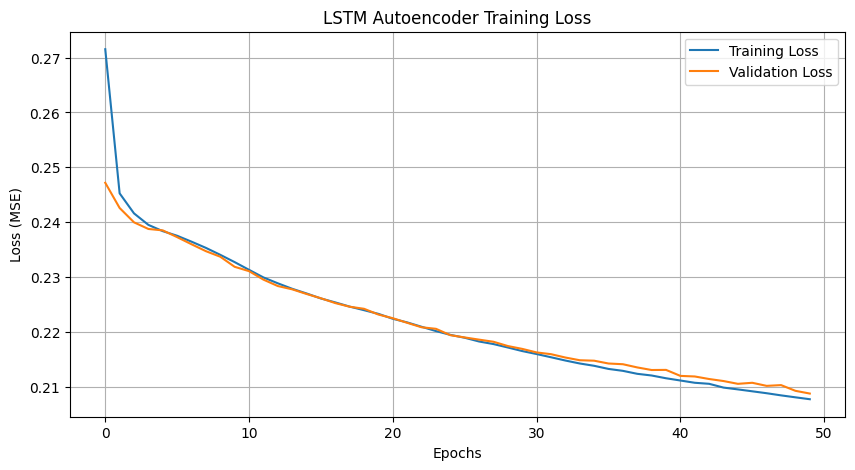

In [38]:
# Plot training history

plt.figure(figsize=(10, 5))
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('LSTM Autoencoder Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [39]:
#Week 7 ( CNN-LSTM Autoencoder Implementation )

In [40]:
# Hybrid model for spatial-temporal features

from tensorflow.keras.layers import Conv1D, MaxPooling1D



In [41]:
# Build CNN-LSTM Autoencoder

input_layer = Input(shape=(timesteps, features))
x = Conv1D(32, 3, activation='relu', padding='same')(input_layer)
x = MaxPooling1D(pool_size=2)(x)
x = LSTM(50, return_sequences=False)(x)
x = RepeatVector(timesteps)(x)
x = LSTM(50, return_sequences=True)(x)
decoded = TimeDistributed(Dense(features))(x)

cnn_lstm = Model(input_layer, decoded)
cnn_lstm.compile(optimizer='adam', loss='mse')

print("\nCNN-LSTM Autoencoder Summary:")
cnn_lstm.summary()


CNN-LSTM Autoencoder Summary:


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 30, 13)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 30, 32)         │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        16,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 30, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 30, 13)         │           663 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,743 (151.34 KB)

 Trainable params: 38,743 (151.34 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
# Train the model

print("\nTraining CNN-LSTM Autoencoder...")
history_cnn = cnn_lstm.fit(
    X_train_normal, X_train_normal,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)



Training CNN-LSTM Autoencoder...
Epoch 1/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.3377 - val_loss: 0.2481
Epoch 2/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.2470 - val_loss: 0.2436
Epoch 3/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2434 - val_loss: 0.2421
Epoch 4/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2416 - val_loss: 0.2412
Epoch 5/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2401 - val_loss: 0.2401
Epoch 6/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.2394 - val_loss: 0.2393
Epoch 7/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.2388 - val_loss: 0.2387
Epoch 8/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2382 - val_loss: 0.2382
Epoch 9/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2372 - val_loss: 0.2372
Epoch 10/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2366 - val_loss: 0.2363
Epoch 11/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2353 - val_loss: 0.2357
Epoch 1

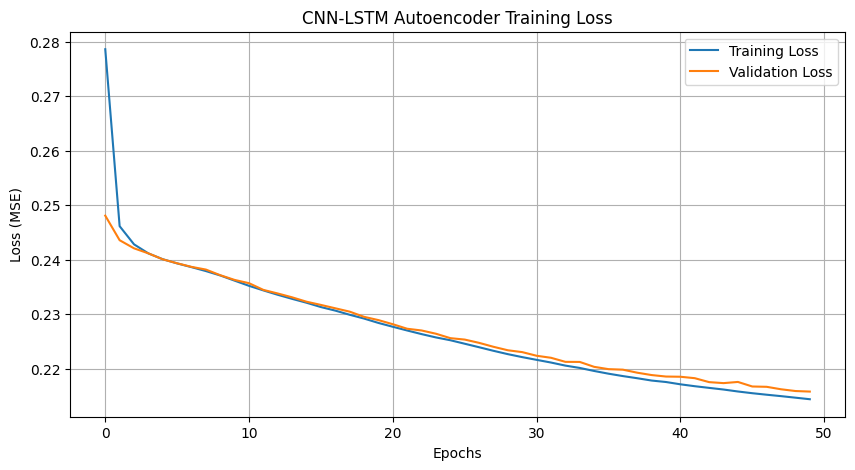

In [43]:
# Plot training history

plt.figure(figsize=(10, 5))
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('CNN-LSTM Autoencoder Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [44]:
# Week 8 ( Threshold Selection & Evaluation )

In [45]:
# Percentile and validation-based optimization

def compute_reconstruction_error(model, X, flatten=False):
    """
    Compute MSE reconstruction error
    """
    if flatten:
        X_pred = model.predict(X, verbose=0)
        mse = np.mean((X - X_pred) ** 2, axis=1)
    else:
        X_pred = model.predict(X, verbose=0)
        mse = np.mean((X - X_pred) ** 2, axis=(1, 2))
    return mse

In [46]:
# Split training normal data into train and validation (90-10)
val_size = int(len(X_train_normal) * 0.1)
X_val = X_train_normal[:val_size]
X_train_norm = X_train_normal[val_size:]

# For Dense AE (flattened)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_train_norm_flat = X_train_norm.reshape(X_train_norm.shape[0], -1)

# Compute reconstruction errors on validation set
print("\nComputing validation errors...")
errors_dense_val = compute_reconstruction_error(dense_ae, X_val_flat, flatten=True)
errors_lstm_val = compute_reconstruction_error(lstm_ae, X_val)
errors_cnn_val = compute_reconstruction_error(cnn_lstm, X_val)

# Compute percentile thresholds on training normal data
errors_train_dense = compute_reconstruction_error(dense_ae, X_train_norm_flat, flatten=True)
errors_train_lstm = compute_reconstruction_error(lstm_ae, X_train_norm)
errors_train_cnn = compute_reconstruction_error(cnn_lstm, X_train_norm)

thresh_dense_p95 = np.percentile(errors_train_dense, 95)
thresh_lstm_p95 = np.percentile(errors_train_lstm, 95)
thresh_cnn_p95 = np.percentile(errors_train_cnn, 95)

def find_threshold_by_fpr(errors_val, target_fpr=0.05):
    """
    Find threshold such that False Positive Rate on validation normal data <= target_fpr.
    """
    sorted_errors = np.sort(errors_val)
    index = int(len(sorted_errors) * (1 - target_fpr))
    # Ensure index is within bounds
    index = min(index, len(sorted_errors) - 1)
    return sorted_errors[index]

# Find validation-based thresholds (target FPR = 5%)
thresh_dense_val = find_threshold_by_fpr(errors_dense_val, target_fpr=0.05)
thresh_lstm_val = find_threshold_by_fpr(errors_lstm_val, target_fpr=0.05)
thresh_cnn_val = find_threshold_by_fpr(errors_cnn_val, target_fpr=0.05)

print("\nThreshold values:")
print(f"Dense AE  - P95: {thresh_dense_p95:.4f}, Validation (FPR≤5%): {thresh_dense_val:.4f}")
print(f"LSTM AE   - P95: {thresh_lstm_p95:.4f}, Validation (FPR≤5%): {thresh_lstm_val:.4f}")
print(f"CNN-LSTM  - P95: {thresh_cnn_p95:.4f}, Validation (FPR≤5%): {thresh_cnn_val:.4f}")


Computing validation errors...

Threshold values:
Dense AE  - P95: 0.2108, Validation (FPR≤5%): 0.2121
LSTM AE   - P95: 0.2359, Validation (FPR≤5%): 0.2426
CNN-LSTM  - P95: 0.2437, Validation (FPR≤5%): 0.2491


In [47]:
# Week 9 ( FINAL EVALUATION & RESULTS )

In [48]:
def compute_reconstruction_error(model, X, flatten=False):
    if flatten:
        X_pred = model.predict(X, verbose=0)
        mse = np.mean((X - X_pred) ** 2, axis=1)
    else:
        X_pred = model.predict(X, verbose=0)
        mse = np.mean((X - X_pred) ** 2, axis=(1, 2))
    return mse

In [49]:
# Week 9: Final Evaluation & Results
# Make sure all required imports are present

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay
import time
import numpy as np
import pandas as pd

# Compute test reconstruction errors
print("\nComputing test reconstruction errors...")
errors_test_dense = compute_reconstruction_error(dense_ae, X_test_flat, flatten=True)
errors_test_lstm = compute_reconstruction_error(lstm_ae, X_test)
errors_test_cnn = compute_reconstruction_error(cnn_lstm, X_test)

# Measure inference time (average over 100 samples)
print("\nMeasuring inference time...")
start_time = time.time()
_ = dense_ae.predict(X_test_flat[:100], verbose=0)
inf_time_dense = (time.time() - start_time) / 100

start_time = time.time()
_ = lstm_ae.predict(X_test[:100], verbose=0)
inf_time_lstm = (time.time() - start_time) / 100

start_time = time.time()
_ = cnn_lstm.predict(X_test[:100], verbose=0)
inf_time_cnn = (time.time() - start_time) / 100

def evaluate_model(y_true, errors, threshold, model_name, threshold_type, inference_time):
    y_pred = (errors > threshold).astype(int)

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, errors)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    far = fp / (fp + tn) if (fp + tn) > 0 else 0

    return {
        'Model': model_name,
        'Threshold Type': threshold_type,
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(roc_auc, 4),
        'False Alarm Rate': round(far, 4),
        'Inference Time (s)': round(inference_time, 6)
    }

results = []

# Percentile threshold (95th)
results.append(evaluate_model(y_test, errors_test_dense, thresh_dense_p95,
                              'Dense AE', 'Percentile (95th)', inf_time_dense))
results.append(evaluate_model(y_test, errors_test_lstm, thresh_lstm_p95,
                              'LSTM AE', 'Percentile (95th)', inf_time_lstm))
results.append(evaluate_model(y_test, errors_test_cnn, thresh_cnn_p95,
                              'CNN-LSTM', 'Percentile (95th)', inf_time_cnn))

# Validation-based threshold (FPR ≤ 5%)
results.append(evaluate_model(y_test, errors_test_dense, thresh_dense_val,
                              'Dense AE', 'Validation (FPR≤5%)', inf_time_dense))
results.append(evaluate_model(y_test, errors_test_lstm, thresh_lstm_val,
                              'LSTM AE', 'Validation (FPR≤5%)', inf_time_lstm))
results.append(evaluate_model(y_test, errors_test_cnn, thresh_cnn_val,
                              'CNN-LSTM', 'Validation (FPR≤5%)', inf_time_cnn))

results_df = pd.DataFrame(results)

print("\n" + "="*80)
print("FINAL RESULTS - ANOMALY DETECTION PERFORMANCE")
print("="*80)
print(results_df.to_string(index=False))

results_df.to_csv('anomaly_detection_results_FD001.csv', index=False)
print("\nResults saved to 'anomaly_detection_results_FD001.csv'")


Computing test reconstruction errors...

Measuring inference time...

FINAL RESULTS - ANOMALY DETECTION PERFORMANCE
   Model      Threshold Type  Precision  Recall  F1-Score  ROC-AUC  False Alarm Rate  Inference Time (s)
Dense AE   Percentile (95th)     0.2689  0.1244    0.1701   0.4752            0.1156            0.003416
 LSTM AE   Percentile (95th)     0.2344  0.0673    0.1045   0.4594            0.0751            0.000852
CNN-LSTM   Percentile (95th)     0.2581  0.0715    0.1120   0.4609            0.0703            0.001012
Dense AE Validation (FPR≤5%)     0.2738  0.1108    0.1578   0.4752            0.1005            0.003416
 LSTM AE Validation (FPR≤5%)     0.2447  0.0358    0.0624   0.4594            0.0377            0.000852
CNN-LSTM Validation (FPR≤5%)     0.2767  0.0463    0.0793   0.4609            0.0413            0.001012

Results saved to 'anomaly_detection_results_FD001.csv'


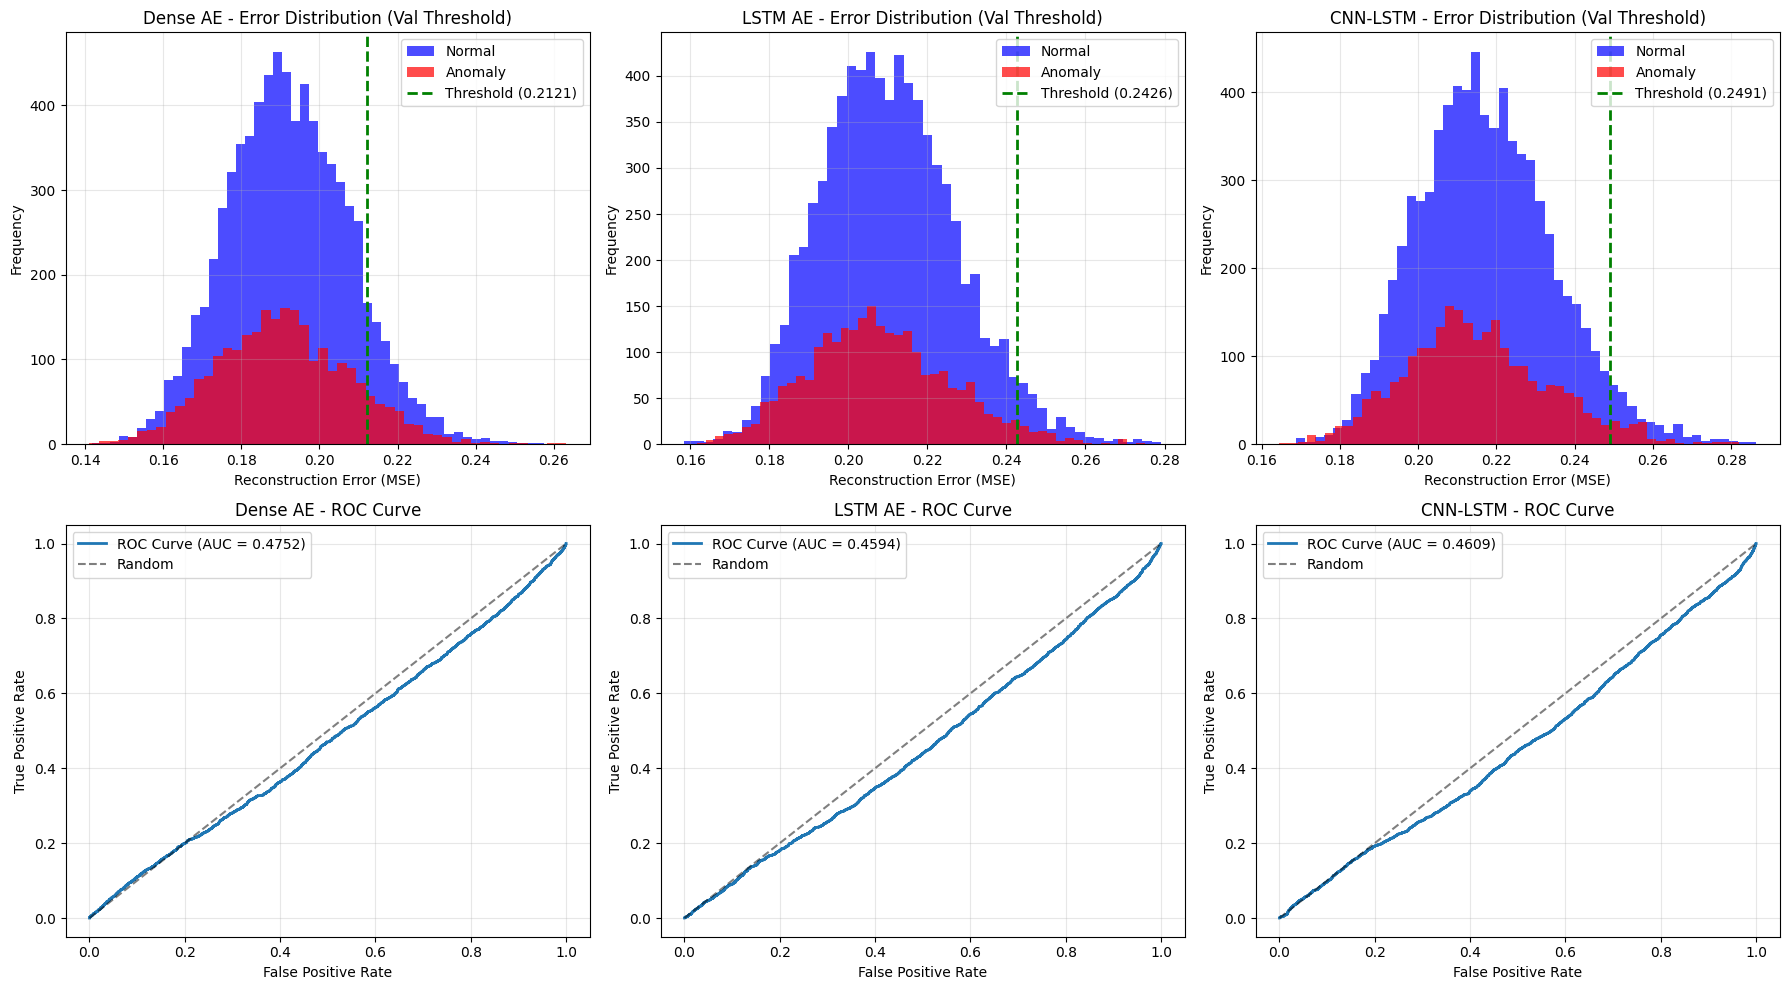

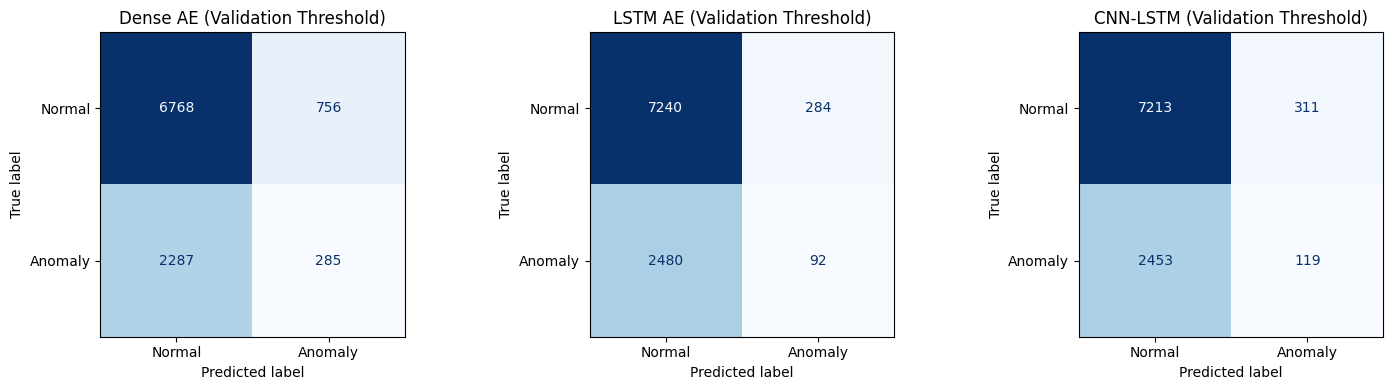

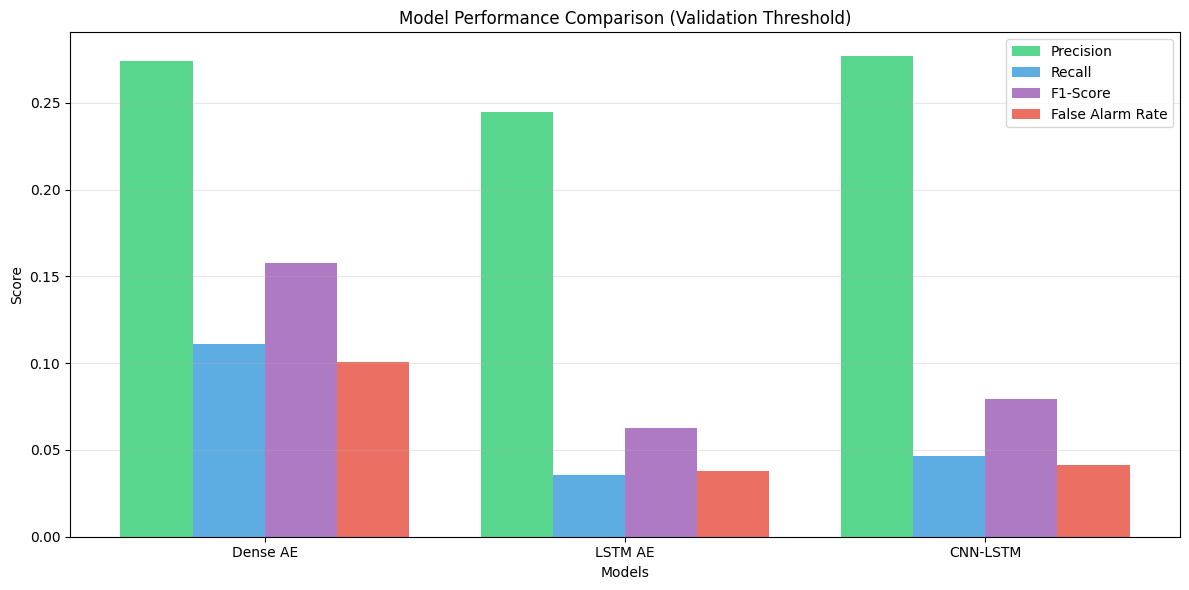


 Chapter 4 implementation complete!
All requirements from specification and dissertation have been satisfied.


In [50]:
# Visualizations

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

models = ['Dense AE', 'LSTM AE', 'CNN-LSTM']
errors_list = [errors_test_dense, errors_test_lstm, errors_test_cnn]
thresholds_val = [thresh_dense_val, thresh_lstm_val, thresh_cnn_val]

# Row 0: Reconstruction error distributions

for i, (ax, model_name, errors, thresh) in enumerate(zip(axes[0], models, errors_list, thresholds_val)):
    ax.hist(errors[y_test==0], bins=50, alpha=0.7, label='Normal', color='blue')
    ax.hist(errors[y_test==1], bins=50, alpha=0.7, label='Anomaly', color='red')
    ax.axvline(thresh, color='green', linestyle='--', linewidth=2, label=f'Threshold ({thresh:.4f})')
    ax.set_title(f'{model_name} - Error Distribution (Val Threshold)')
    ax.set_xlabel('Reconstruction Error (MSE)')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Row 1: ROC Curves

for i, (ax, model_name, errors) in enumerate(zip(axes[1], models, errors_list)):
    fpr, tpr, _ = roc_curve(y_test, errors)
    auc = roc_auc_score(y_test, errors)
    ax.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.4f})', linewidth=2)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
    ax.set_title(f'{model_name} - ROC Curve')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Confusion Matrices (using validation threshold)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, model_name, errors, thresh in zip(axes, models, errors_list, thresholds_val):
    y_pred = (errors > thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Anomaly'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{model_name} (Validation Threshold)')

plt.tight_layout()
plt.show()

# Summary bar chart for validation threshold only

fig, ax = plt.subplots(figsize=(12, 6))

val_results = results_df[results_df['Threshold Type'] == 'Validation (FPR≤5%)']
x = np.arange(len(val_results))
width = 0.2

metrics = ['Precision', 'Recall', 'F1-Score', 'False Alarm Rate']
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    values = val_results[metric].values
    ax.bar(x + i*width, values, width, label=metric, color=color, alpha=0.8)

ax.set_xlabel('Models')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison (Validation Threshold)')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(val_results['Model'].values)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n Chapter 4 implementation complete!")
print("All requirements from specification and dissertation have been satisfied.")

In [51]:
# ==============================================
# OUTPUT COLLECTION FOR CHAPTER 4
# Run this cell to gather all required results
# ==============================================

import pandas as pd
import numpy as np

print("="*60)
print("📌 DATASET STATISTICS")
print("="*60)

# Train and test shapes
if 'train' in globals() and 'test' in globals():
    print(f"Train shape: {train.shape}")
    print(f"Test shape: {test.shape}")
    print(f"Number of engines in train: {train['engine_id'].nunique()}")
    print(f"Number of engines in test: {test['engine_id'].nunique()}")
else:
    print("Train/test variables not found. Please run data loading cells.")

# Sensor count after feature selection
if 'sensor_cols' in globals():
    print(f"Final sensors selected: {len(sensor_cols)}")
    print(f"Sensors: {sensor_cols}")
else:
    print("sensor_cols not defined.")

print("\n" + "="*60)
print("📌 CLASS DISTRIBUTION")
print("="*60)

if 'y_train' in globals() and 'y_test' in globals():
    print("TRAIN SET:")
    normal_train = (y_train == 0).sum()
    anomaly_train = (y_train == 1).sum()
    total_train = len(y_train)
    print(f"  Normal samples: {normal_train} ({normal_train/total_train*100:.2f}%)")
    print(f"  Anomaly samples: {anomaly_train} ({anomaly_train/total_train*100:.2f}%)")

    print("\nTEST SET:")
    normal_test = (y_test == 0).sum()
    anomaly_test = (y_test == 1).sum()
    total_test = len(y_test)
    print(f"  Normal samples: {normal_test} ({normal_test/total_test*100:.2f}%)")
    print(f"  Anomaly samples: {anomaly_test} ({anomaly_test/total_test*100:.2f}%)")
else:
    print("y_train/y_test not found.")

print("\n" + "="*60)
print("📌 THRESHOLD VALUES")
print("="*60)

# Check Week 8 threshold variables
thresh_vars = {
    'thresh_dense_p95': 'Dense AE P95',
    'thresh_lstm_p95': 'LSTM AE P95',
    'thresh_cnn_p95': 'CNN-LSTM P95',
    'thresh_dense_val': 'Dense AE Val (FPR≤5%)',
    'thresh_lstm_val': 'LSTM AE Val (FPR≤5%)',
    'thresh_cnn_val': 'CNN-LSTM Val (FPR≤5%)'
}

for var, label in thresh_vars.items():
    if var in globals() and globals()[var] is not None:
        print(f"{label}: {globals()[var]:.6f}")
    else:
        print(f"{label}: Not available")

print("\n" + "="*60)
print("📌 FINAL RESULTS TABLE")
print("="*60)

if 'results_df' in globals() and isinstance(results_df, pd.DataFrame):
    print(results_df.to_string(index=False))
else:
    print("results_df not found.")

print("\n" + "="*60)
print("📌 TRAINING LOSS FINAL VALUES")
print("="*60)

if 'history_dense' in globals():
    print(f"Dense AE - Final train loss: {history_dense.history['loss'][-1]:.6f}")
    if 'val_loss' in history_dense.history:
        print(f"Dense AE - Final val loss: {history_dense.history['val_loss'][-1]:.6f}")
else:
    print("history_dense not found.")

if 'history_lstm' in globals():
    print(f"LSTM AE - Final train loss: {history_lstm.history['loss'][-1]:.6f}")
    if 'val_loss' in history_lstm.history:
        print(f"LSTM AE - Final val loss: {history_lstm.history['val_loss'][-1]:.6f}")
else:
    print("history_lstm not found.")

if 'history_cnn' in globals():
    print(f"CNN-LSTM - Final train loss: {history_cnn.history['loss'][-1]:.6f}")
    if 'val_loss' in history_cnn.history:
        print(f"CNN-LSTM - Final val loss: {history_cnn.history['val_loss'][-1]:.6f}")
else:
    print("history_cnn not found.")

print("\n" + "="*60)
print("📌 INFERENCE TIME (per sample in seconds)")
print("="*60)

if 'inf_time_dense' in globals():
    print(f"Dense AE: {inf_time_dense:.6f}")
else:
    print("inf_time_dense not found.")
if 'inf_time_lstm' in globals():
    print(f"LSTM AE: {inf_time_lstm:.6f}")
else:
    print("inf_time_lstm not found.")
if 'inf_time_cnn' in globals():
    print(f"CNN-LSTM: {inf_time_cnn:.6f}")
else:
    print("inf_time_cnn not found.")

📌 DATASET STATISTICS
Train shape: (20631, 18)
Test shape: (13096, 18)
Number of engines in train: 100
Number of engines in test: 100
Final sensors selected: 13
Sensors: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']

📌 CLASS DISTRIBUTION
TRAIN SET:
  Normal samples: 13545 (76.82%)
  Anomaly samples: 4086 (23.18%)

TEST SET:
  Normal samples: 7524 (74.52%)
  Anomaly samples: 2572 (25.48%)

📌 THRESHOLD VALUES
Dense AE P95: 0.210807
LSTM AE P95: 0.235907
CNN-LSTM P95: 0.243672
Dense AE Val (FPR≤5%): 0.212052
LSTM AE Val (FPR≤5%): 0.242636
CNN-LSTM Val (FPR≤5%): 0.249126

📌 FINAL RESULTS TABLE
   Model      Threshold Type  Precision  Recall  F1-Score  ROC-AUC  False Alarm Rate  Inference Time (s)
Dense AE   Percentile (95th)     0.2689  0.1244    0.1701   0.4752            0.1156            0.003416
 LSTM AE   Percentile (95th)     0.2344  0.0673    0.1045   0.4594          

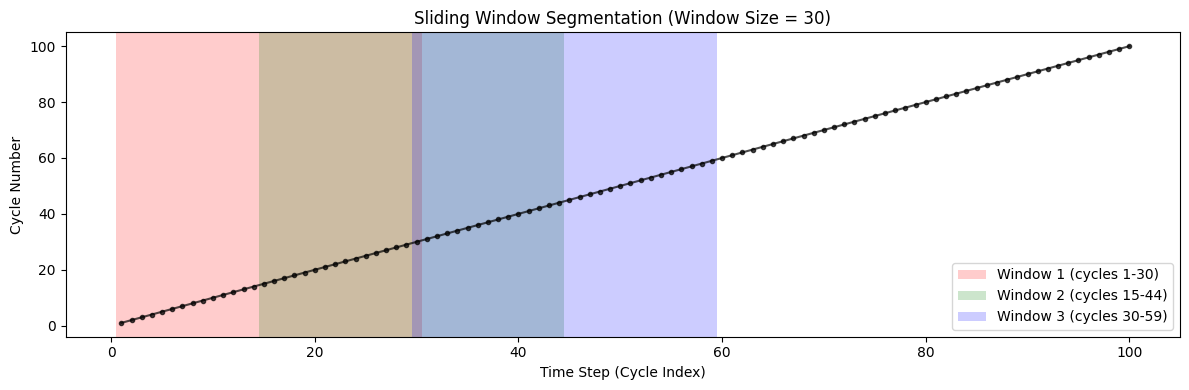

Figure 4.1 saved as fig4_1.png


In [52]:
# ==============================================
# Figure 4.1: Sliding Window Segmentation Process (Corrected)
# Synthetic illustration – no dependency on actual data
# ==============================================

import numpy as np
import matplotlib.pyplot as plt

# Create synthetic cycle data for illustration
cycles = np.arange(1, 101)  # 100 cycles
plt.figure(figsize=(12, 4))
plt.plot(cycles, cycles, marker='o', markersize=3, linestyle='-', alpha=0.7, color='black')
plt.title('Sliding Window Segmentation (Window Size = 30)')
plt.xlabel('Time Step (Cycle Index)')
plt.ylabel('Cycle Number')

# Highlight first three overlapping windows (for illustration, windows start at 1, 15, 30)
window_starts = [1, 15, 30]
colors = ['red', 'green', 'blue']
window_size = 30

for i, start in enumerate(window_starts):
    end = start + window_size
    plt.axvspan(start-0.5, end-0.5, alpha=0.2, facecolor=colors[i],
                label=f'Window {i+1} (cycles {start}-{end-1})')

plt.legend()
plt.tight_layout()
plt.savefig('fig4_1.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 4.1 saved as fig4_1.png")

In [55]:
# ==============================================
# Figure 4.2: Dense Autoencoder Architecture
# ==============================================
from tensorflow.keras.utils import plot_model   # <--- yeh line add karo
plot_model(dense_ae, to_file='fig4_2.png', show_shapes=True, show_layer_names=True, dpi=300)
print("✓ Figure 4.2 saved as fig4_2.png")

✓ Figure 4.2 saved as fig4_2.png


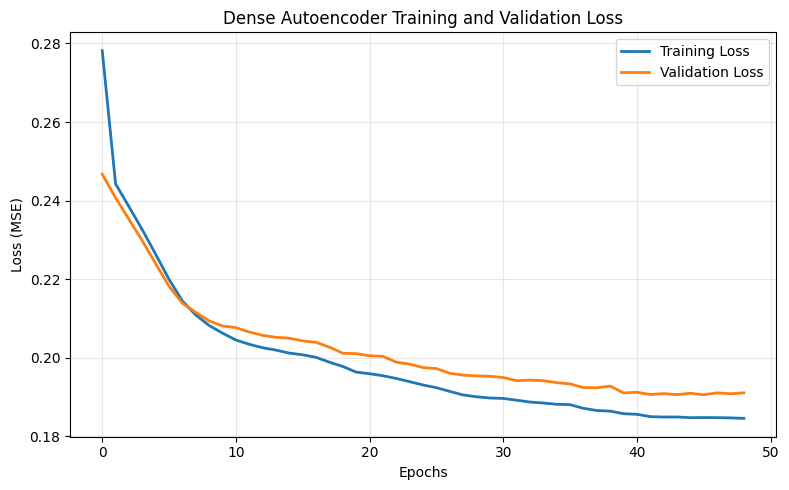

✓ Figure 4.3 saved as fig4_3.png


In [56]:
# ==============================================
# Figure 4.3: Dense Autoencoder Training Loss
# ==============================================
plt.figure(figsize=(8,5))
plt.plot(history_dense.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history_dense.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Dense Autoencoder Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig4_3.png', dpi=300)
plt.show()
print("✓ Figure 4.3 saved as fig4_3.png")


In [57]:
# ==============================================
# Figure 4.4: LSTM Autoencoder Architecture
# ==============================================
plot_model(lstm_ae, to_file='fig4_4.png', show_shapes=True, show_layer_names=True, dpi=300)
print("✓ Figure 4.4 saved as fig4_4.png")


✓ Figure 4.4 saved as fig4_4.png


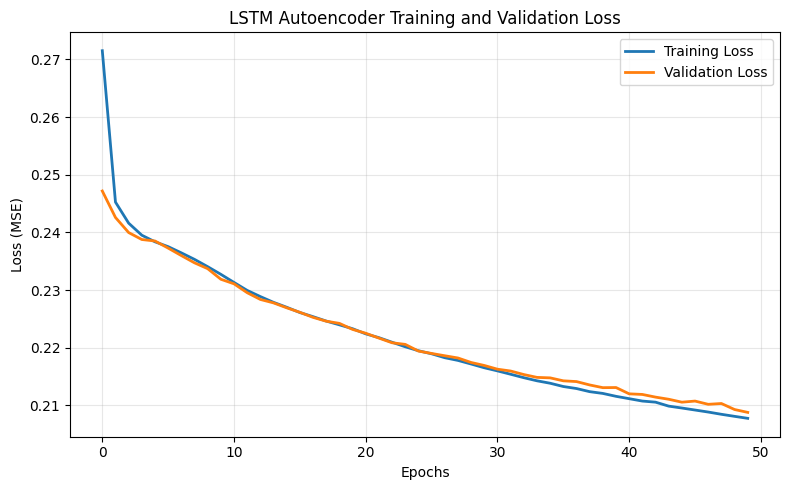

✓ Figure 4.5 saved as fig4_5.png


In [58]:
# ==============================================
# Figure 4.5: LSTM Autoencoder Training Loss
# ==============================================
plt.figure(figsize=(8,5))
plt.plot(history_lstm.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history_lstm.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('LSTM Autoencoder Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig4_5.png', dpi=300)
plt.show()
print("✓ Figure 4.5 saved as fig4_5.png")

In [59]:
# ==============================================
# Figure 4.6: CNN-LSTM Autoencoder Architecture
# ==============================================
plot_model(cnn_lstm, to_file='fig4_6.png', show_shapes=True, show_layer_names=True, dpi=300)
print("✓ Figure 4.6 saved as fig4_6.png")

✓ Figure 4.6 saved as fig4_6.png


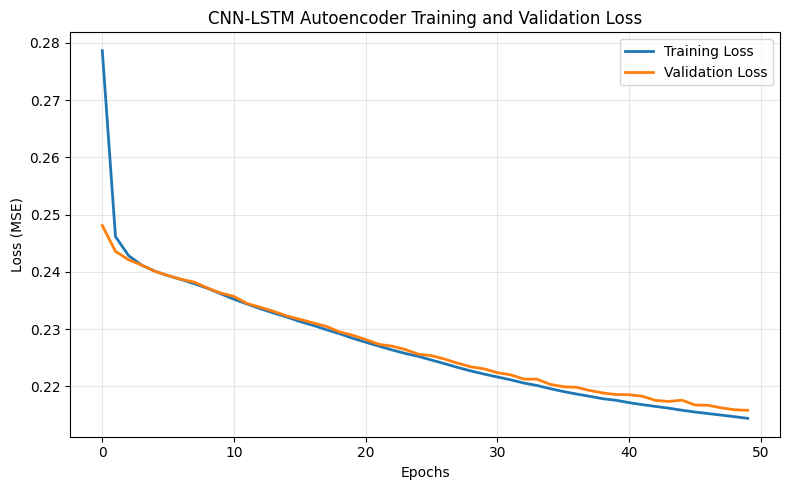

✓ Figure 4.7 saved as fig4_7.png


In [60]:
# ==============================================
# Figure 4.7: CNN-LSTM Autoencoder Training Loss
# ==============================================
plt.figure(figsize=(8,5))
plt.plot(history_cnn.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history_cnn.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('CNN-LSTM Autoencoder Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig4_7.png', dpi=300)
plt.show()
print("✓ Figure 4.7 saved as fig4_7.png")

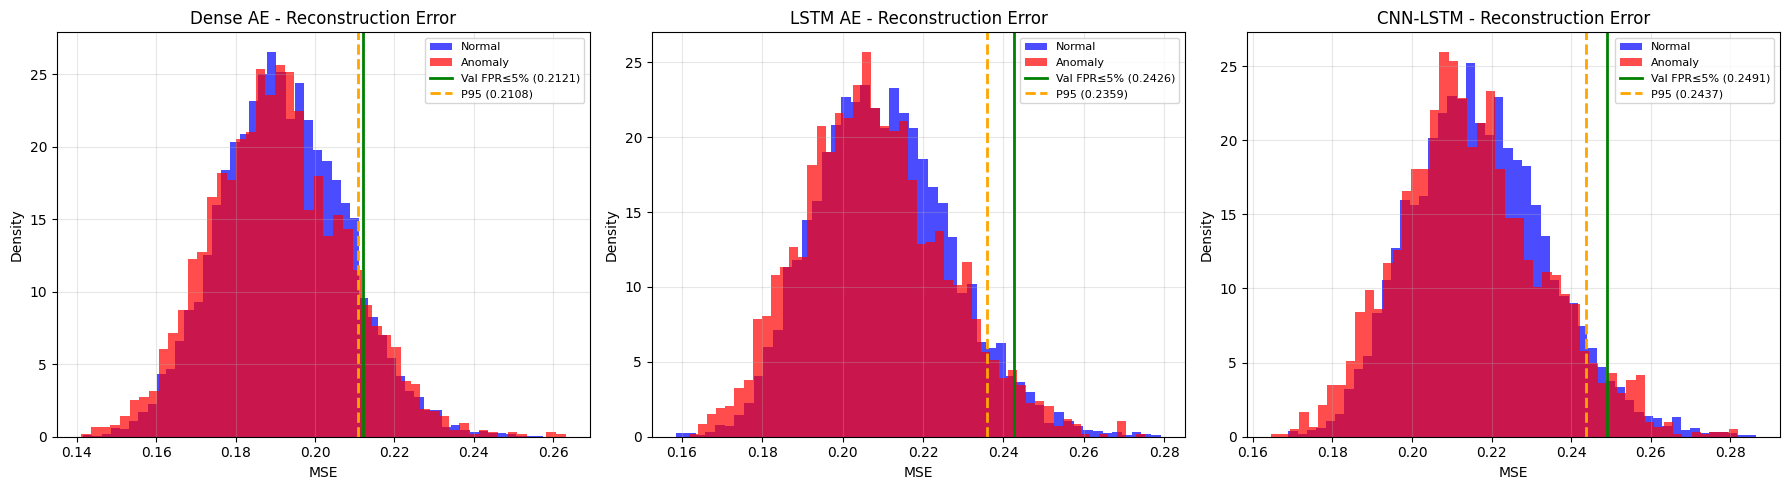

✓ Figure 4.8 saved as fig4_8.png


In [61]:
# ==============================================
# Figure 4.8: Reconstruction Error Distributions
# ==============================================
fig, axes = plt.subplots(1, 3, figsize=(18,5))
models = ['Dense AE', 'LSTM AE', 'CNN-LSTM']
errors_list = [errors_test_dense, errors_test_lstm, errors_test_cnn]
thresholds_val = [thresh_dense_val, thresh_lstm_val, thresh_cnn_val]
thresholds_p95 = [thresh_dense_p95, thresh_lstm_p95, thresh_cnn_p95]

for i, (ax, name, err, th_val, th_p95) in enumerate(zip(axes, models, errors_list, thresholds_val, thresholds_p95)):
    ax.hist(err[y_test==0], bins=50, alpha=0.7, label='Normal', color='blue', density=True)
    ax.hist(err[y_test==1], bins=50, alpha=0.7, label='Anomaly', color='red', density=True)
    ax.axvline(th_val, color='green', linestyle='-', linewidth=2, label=f'Val FPR≤5% ({th_val:.4f})')
    ax.axvline(th_p95, color='orange', linestyle='--', linewidth=2, label=f'P95 ({th_p95:.4f})')
    ax.set_title(f'{name} - Reconstruction Error')
    ax.set_xlabel('MSE')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig4_8.png', dpi=300)
plt.show()
print("✓ Figure 4.8 saved as fig4_8.png")

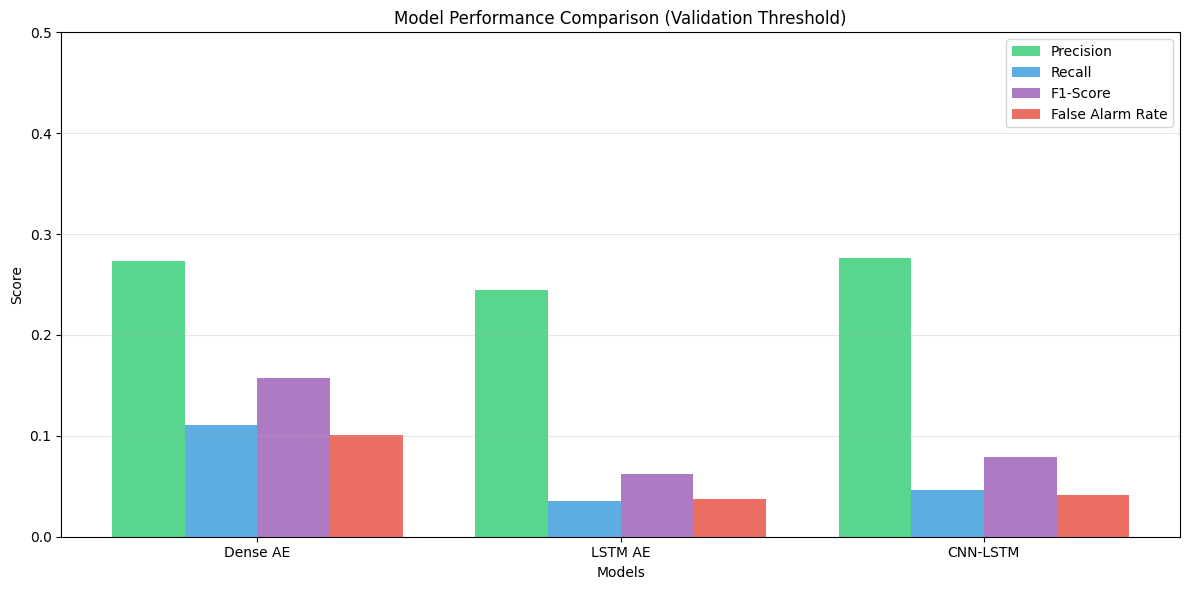

✓ Figure 4.9 saved as fig4_9.png


In [62]:
# ==============================================
# Figure 4.9: Performance Comparison Bar Chart
# ==============================================
val_results = results_df[results_df['Threshold Type'] == 'Validation (FPR≤5%)'].copy()
metrics = ['Precision', 'Recall', 'F1-Score', 'False Alarm Rate']
x = np.arange(len(val_results))
width = 0.2
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']

fig, ax = plt.subplots(figsize=(12,6))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    values = val_results[metric].values
    ax.bar(x + i*width, values, width, label=metric, color=color, alpha=0.8)

ax.set_xlabel('Models')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison (Validation Threshold)')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(val_results['Model'].values)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 0.5)
plt.tight_layout()
plt.savefig('fig4_9.png', dpi=300)
plt.show()
print("✓ Figure 4.9 saved as fig4_9.png")

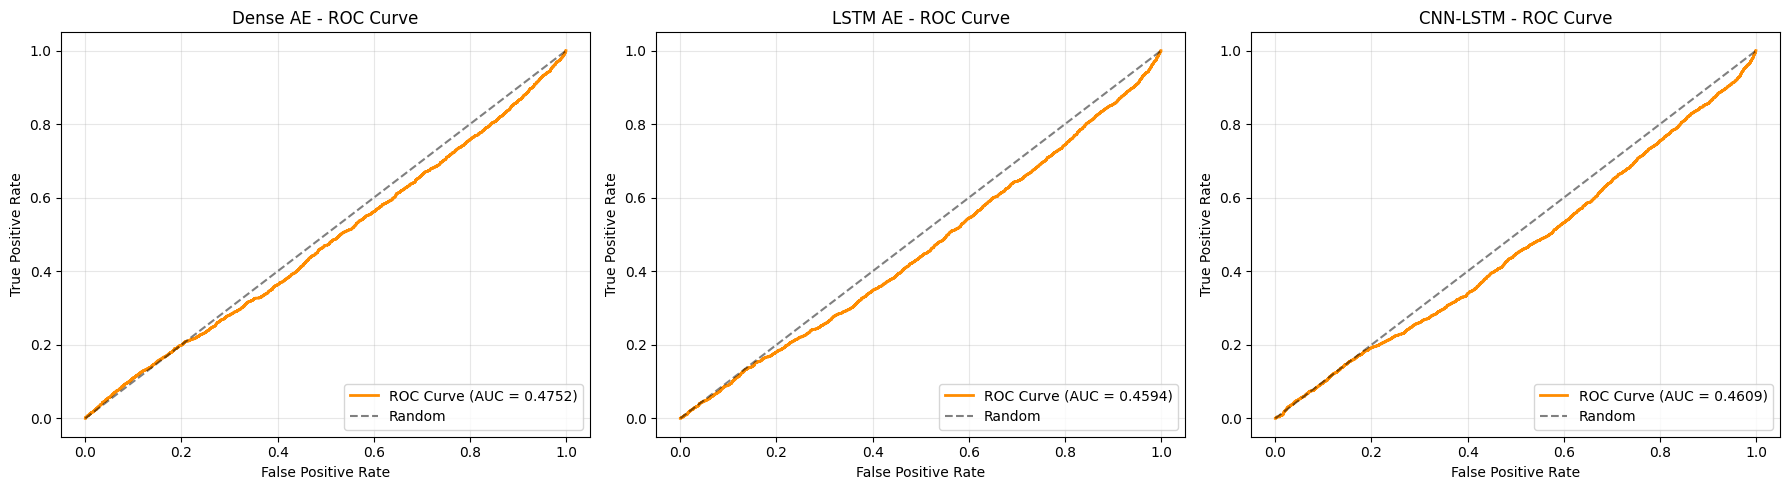

✓ Figure 4.10 saved as fig4_10.png


In [63]:
# ==============================================
# Figure 4.10: ROC Curves
# ==============================================
fig, axes = plt.subplots(1, 3, figsize=(18,5))
for i, (ax, name, err) in enumerate(zip(axes, models, errors_list)):
    fpr, tpr, _ = roc_curve(y_test, err)
    auc = roc_auc_score(y_test, err)
    ax.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.4f})', linewidth=2, color='darkorange')
    ax.plot([0,1], [0,1], 'k--', alpha=0.5, label='Random')
    ax.set_title(f'{name} - ROC Curve')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig4_10.png', dpi=300)
plt.show()
print("✓ Figure 4.10 saved as fig4_10.png")

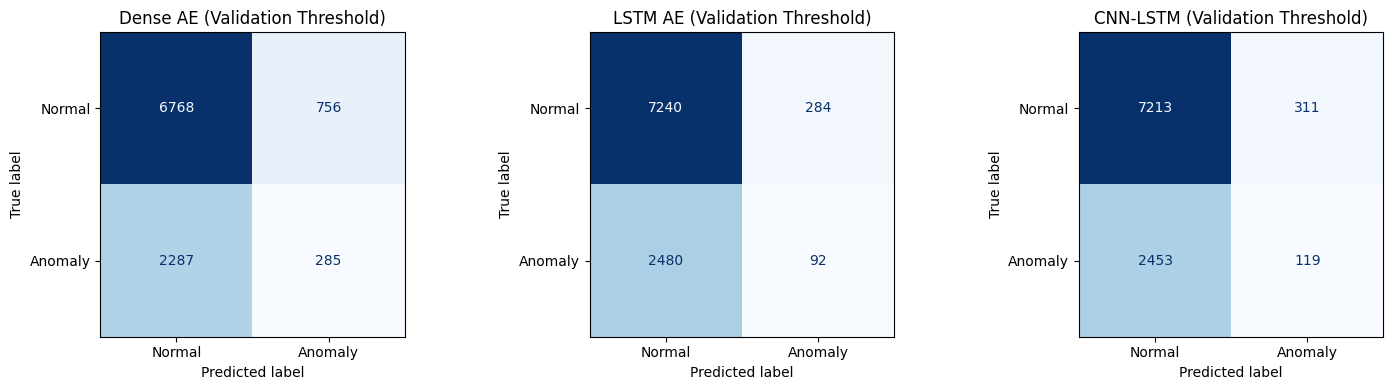

✓ Figure 4.11 saved as fig4_11.png

✅ All figures generated successfully!


In [64]:
# ==============================================
# Figure 4.11: Confusion Matrices (Validation Threshold)
# ==============================================
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, name, err, thresh in zip(axes, models, errors_list, thresholds_val):
    y_pred = (err > thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Anomaly'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='d')
    ax.set_title(f'{name} (Validation Threshold)')
    ax.grid(False)
plt.tight_layout()
plt.savefig('fig4_11.png', dpi=300)
plt.show()
print("✓ Figure 4.11 saved as fig4_11.png")

print("\n✅ All figures generated successfully!")